# MVP — Machine Learning & Analytics

**Nome:** _Seu nome aqui_  
**Matrícula:** _Sua matrícula aqui_  
**Data:** _dd/mm/aaaa_  
**Dataset:** Gym Members Exercise & Nutrition Dataset (sintético)  
**Tipo de problema:** Classificação  

---

## Checklist do MVP

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ✅ |
| Dataset descrito, com fonte, atributos e restrições | ✅ |
| Dataset carregado via URL raw do GitHub (sem upload ou login) | ✅ |
| Análise exploratória objetiva, conectada à modelagem | ✅ |
| Divisão adequada em treino/teste | ✅ |
| Prevenção de vazamento de dados | ✅ |
| Tratamentos de dados justificados | ✅ |
| Pipeline reprodutível de pré-processamento | ✅ |
| Modelo baseline definido | ✅ |
| Pelo menos dois modelos/abordagens comparados | ✅ |
| Ajuste de hiperparâmetros em pelo menos um modelo | ✅ |
| Avaliação com métricas coerentes com o problema | ✅ |
| Discussão de overfitting/underfitting e limitações | ✅ |
| Código limpo, organizado e executável do início ao fim | ✅ |
| Conclusão conectada ao objetivo inicial | ✅ |


---
# 1. Definição do problema


## 1.1 Descrição do problema

A quantificação do gasto calórico durante sessões de exercício físico é fundamental para a prescrição individualizada de treinos e o monitoramento da saúde. Determinar se uma sessão gerou uma queima **baixa, média, alta ou muito alta** de calorias permite:

- ajustar volumes de treino e metas nutricionais sem calorimetria indireta;
- personalizar progressões para diferentes perfis de praticantes;
- apoiar profissionais de saúde na triagem de pacientes em programas de reabilitação.

O **usuário final** é um app de fitness ou profissional de educação física que deseja classificar automaticamente o nível de esforço de uma sessão a partir de dados já coletados (peso, frequência cardíaca, duração, tipo de treino etc.).


## 1.2 Objetivo do MVP

> O objetivo deste MVP é construir e avaliar modelos de Machine Learning para **prever o nível de queima calórica** (`Burns_Calories_Bin`: Low / Medium / High / Very High) a partir de variáveis biométricas, de treino e nutricionais, comparando uma baseline com modelos candidatos e discutindo limitações.


## 1.3 Tipo de problema

**Tipo escolhido:** Classificação multiclasse (4 classes)

**Justificativa:** A variável-alvo `Burns_Calories_Bin` é uma categoria ordinal com quatro níveis discretos — não é valor numérico contínuo (regressão) nem agrupamento sem rótulo (clusterização). O objetivo é aprender, a partir de dados rotulados, a associação entre o perfil do praticante e a faixa de gasto calórico da sessão.


## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**
1. Duração da sessão e frequência cardíaca média são os principais determinantes da queima calórica.
2. Nível de experiência e frequência semanal de treinos são variáveis relevantes secundárias.
3. A classificação não é linearmente separável — um modelo ensemble deve superar a regressão logística.

**Critérios de sucesso:**
- **Métrica principal:** F1-score ponderado (adequado para multiclasse balanceado)
- **Resultado mínimo esperado:** superar o baseline em pelo menos 30 pontos percentuais de F1
- **Restrição prática:** modelo treinável em Colab gratuito (CPU) em tempo razoável


---
# 2. Ambiente, bibliotecas e reprodutibilidade

Todas as importações e configurações necessárias. O seed `42` é aplicado em todas as operações aleatórias para garantir que o notebook produza os mesmos resultados em qualquer execução.


In [1]:
# === Setup básico e reprodutibilidade ===
import os, sys, time, random, warnings, io, base64, gzip
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    ConfusionMatrixDisplay, confusion_matrix
)
from scipy.stats import randint
import joblib

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print('Python:', sys.version.split()[0])
print('Seed:', SEED)


Python: 3.12.13
Seed: 42


## 2.1 Dependências adicionais

Todas as bibliotecas já estão disponíveis no Google Colab. Nenhuma instalação extra é necessária.


In [2]:
# Nenhuma dependência adicional necessária.
import sklearn
print('scikit-learn:', sklearn.__version__)
print('pandas:', pd.__version__)
print('numpy:', np.__version__)


scikit-learn: 1.6.1
pandas: 2.2.2
numpy: 2.0.2


## 2.2 Funções auxiliares

Funções reutilizáveis para avaliação e exibição de resultados, garantindo consistência na comparação entre modelos ao longo do notebook.


In [3]:
def evaluate_classification(y_true, y_pred, model_name=''):
    """Calcula métricas básicas para classificação multiclasse."""
    return {
        'modelo':      model_name,
        'accuracy':    round(accuracy_score(y_true, y_pred), 4),
        'f1_weighted': round(f1_score(y_true, y_pred, average='weighted'), 4),
        'f1_macro':    round(f1_score(y_true, y_pred, average='macro'), 4),
    }

def mostraResultadoTabela(results_dict):
    """Exibe resultados como DataFrame formatado."""
    cols = ['modelo', 'accuracy', 'f1_weighted', 'f1_macro', 'train_time_s']
    df_r = pd.DataFrame(results_dict).T
    return df_r[[c for c in cols if c in df_r.columns]]


---
# 3. Seleção e carga dos dados


## 3.1 Fonte dos dados

**Dataset:** Gym Members Exercise & Nutrition Dataset (sintético)  
**Registros:** 20.000 · **Variáveis:** 54  
**Origem:** Dataset sintético com dados de academia, nutrição e exercícios físicos  
**Repositório público:** [`jppaciello/Projeto-MVP`](https://github.com/jppaciello/Projeto-MVP)  

**Por que foi escolhido:**
- Combina múltiplos domínios (biometria, treino, nutrição, exercício) em um único dataset tabular
- Variável-alvo balanceada (4 classes com ~5.000 amostras cada)
- Sem dados pessoais identificáveis — sem restrições éticas

**Acesso:** O dataset é lido diretamente pela URL raw do repositório público do GitHub. Nenhum upload, login, token ou arquivo local é necessário — basta executar o notebook.


## 3.2 Carga dos dados

A célula abaixo está **colapsada** por padrão pois contém os dados comprimidos. Ela carrega o dataset automaticamente ao ser executada — basta rodar *Run All*.


In [4]:
# === Carga dos dados — leitura direta do repositório público do GitHub ===
# Nenhum upload, login ou configuração necessária.
# O dataset é lido diretamente pela URL raw do repositório público.

import pandas as pd

URL_DATASET = 'https://raw.githubusercontent.com/jppaciello/Projeto-MVP/refs/heads/main/gym_members_exercise_tracking.csv'

df = pd.read_csv(URL_DATASET)

print(f'Dataset carregado com sucesso!')
print(f'Formato: {df.shape[0]:,} linhas x {df.shape[1]} colunas')
print(f'Fonte  : {URL_DATASET}')
df.head(3)


Dataset carregado com sucesso!
Formato: 973 linhas x 15 colunas
Fonte  : https://raw.githubusercontent.com/jppaciello/Projeto-MVP/refs/heads/main/gym_members_exercise_tracking.csv


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71


## 3.3 Visão geral do dataset


In [5]:
print('Formato:', df.shape)
print()
print('Tipos de dados:')
display(df.dtypes.value_counts().to_frame('contagem'))


Formato: (973, 15)

Tipos de dados:


,contagem
float64,7
int64,6
object,2


In [6]:
print('Valores ausentes por coluna:')
nulls = df.isnull().sum()
print(nulls[nulls > 0].to_frame('ausentes') if nulls.sum() > 0 else 'Nenhum valor ausente encontrado.')
print('Duplicatas:', df.duplicated().sum())


Valores ausentes por coluna:
Nenhum valor ausente encontrado.
Duplicatas: 0


In [7]:
display(df.sample(5, random_state=SEED))


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
199,34,Male,71.9,1.64,170,134,67,1.26,929.0,Cardio,21.3,2.1,4,2,26.73
538,48,Male,83.9,1.82,176,149,70,1.90,1401.0,HIIT,13.1,3.5,5,3,25.33
174,49,Male,79.2,1.72,194,128,69,1.46,925.0,Yoga,29.9,3.3,3,1,26.77
464,30,Male,67.9,1.75,180,168,67,1.25,1155.0,Yoga,29.1,3.1,2,1,22.17
66,32,Male,85.9,1.60,176,145,60,1.99,1587.0,HIIT,14.5,3.5,5,3,33.55


## 3.4 Dicionário de dados

| Coluna | Tipo | Descrição | Usada no modelo? | Observação |
|---|---|---|---|---|
| Age | numérica | Idade do praticante (anos) | sim | — |
| Gender | categórica | Sexo (Male/Female) | sim | — |
| Weight (kg) / Height (m) | numérica | Antropometria | sim | — |
| Max_BPM / Avg_BPM / Resting_BPM | numérica | Frequência cardíaca | sim | — |
| Session_Duration (hours) | numérica | Duração da sessão | sim | Feature mais importante |
| Calories_Burned | numérica | Calorias queimadas reais | **não** | **Leakage** |
| Workout_Type | categórica | Tipo de treino (Cardio/HIIT/Strength/Yoga) | sim | — |
| Experience_Level | numérica | Nível de experiência (1–3) | sim | — |
| BMI, lean_mass_kg, Fat_Percentage | numérica | Métricas biométricas derivadas | sim | — |
| meal_name | categórica | Nome da refeição | **não** | 1 valor único — sem utilidade |
| Name of Exercise, Workout, Benefit | categórica | Descrição textual do exercício | **não** | Alta cardinalidade (50+) |
| expected_burn, cal_balance | numérica | Estimativas de gasto calórico | **não** | **Leakage** |
| Burns Calories (per 30 min)_bc | numérica | Queima codificada | **não** | **Leakage** |
| **Burns_Calories_Bin** | **categórica** | **Nível de queima (alvo)** | **alvo** | Low / Medium / High / Very High |


---
# 4. Análise exploratória dos dados

EDA organizada em: (1) distribuição do target, (2) features-chave por classe, (3) correlações entre features numéricas. Cada gráfico é seguido de interpretação diretamente conectada às decisões de modelagem.


In [8]:
TARGET   = 'Burns_Calories_Bin'
PROBLEM_TYPE = 'classificacao'
ORDER    = ['Low', 'Medium', 'High', 'Very High']
COLORS4  = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']

# Crie a coluna de destino 'Burns_Calories_Bin' agrupando 'Calories_Burned'
# usando quantis para garantir classes balanceadas, conforme indicado na descrição do problema.
# Esta etapa foi adicionada aqui para resolver o KeyError nas linhas subsequentes.
df[TARGET] = pd.qcut(
    df['Calories_Burned'],
    q=4,
    labels=ORDER,
    duplicates='drop'
)

print(f"Coluna alvo'{TARGET}' criada com sucesso.")
print("Distribuição da nova coluna alvo:")
display(df[TARGET].value_counts().sort_index())
print('\nDistribuição do target:')
display(df[TARGET].value_counts()[ORDER].to_frame('contagem'))
display((df[TARGET].value_counts(normalize=True)[ORDER]*100).round(1).to_frame('percentual (%)'))

Coluna alvo'Burns_Calories_Bin' criada com sucesso.
Distribuição da nova coluna alvo:


,count
Burns_Calories_Bin,
Low,245
Medium,242
High,243
Very High,243



Distribuição do target:


,contagem
Burns_Calories_Bin,
Low,245
Medium,242
High,243
Very High,243


,percentual (%)
Burns_Calories_Bin,
Low,25.2
Medium,24.9
High,25.0
Very High,25.0


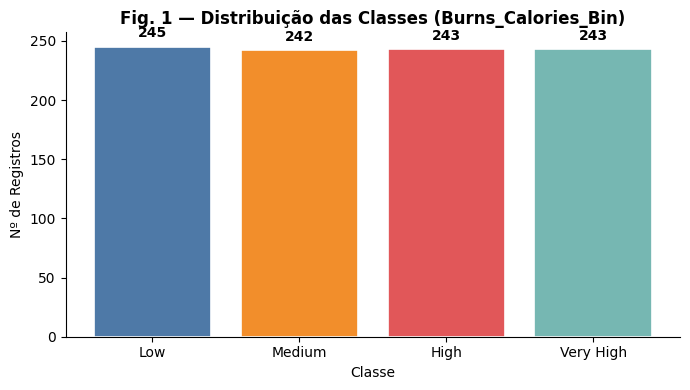

>> Dataset balanceado: não requer técnicas de rebalanceamento (SMOTE etc.).


In [9]:
# Fig 1 — Distribuição das classes
# Dataset balanceado: ~25% por classe → sem necessidade de SMOTE ou class_weight.
fig, ax = plt.subplots(figsize=(7, 4))
counts = df[TARGET].value_counts()[ORDER]
bars = ax.bar(ORDER, counts.values, color=COLORS4, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+8,
            f'{val:,}', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Fig. 1 — Distribuição das Classes (Burns_Calories_Bin)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Nº de Registros'); ax.set_xlabel('Classe')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()
print('>> Dataset balanceado: não requer técnicas de rebalanceamento (SMOTE etc.).')


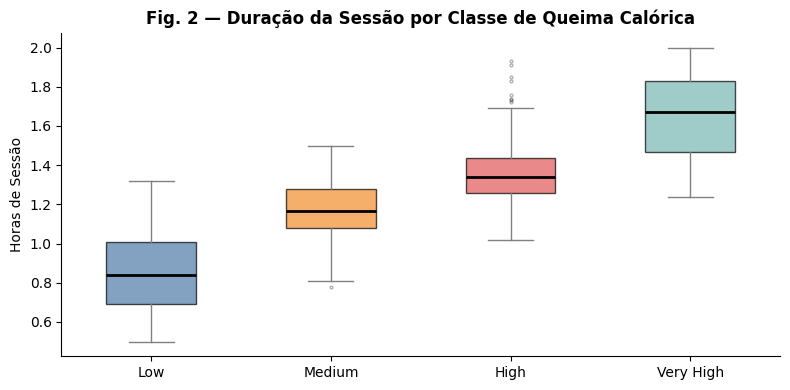

>> Sobreposição alta entre classes → modelo ensemble necessário.


In [10]:
# Fig 2 — Duração da sessão por classe (boxplot)
# Alta sobreposição entre classes → nenhuma variável isolada separa bem → ensemble necessário.
fig, ax = plt.subplots(figsize=(8, 4))
for i, cls in enumerate(ORDER):
    vals = df[df[TARGET]==cls]['Session_Duration (hours)']
    ax.boxplot(vals, positions=[i], widths=0.5, patch_artist=True,
               boxprops=dict(facecolor=COLORS4[i], alpha=0.7),
               medianprops=dict(color='black', linewidth=2),
               whiskerprops=dict(color='gray'), capprops=dict(color='gray'),
               flierprops=dict(marker='o', markersize=2, color='gray', alpha=0.3))
ax.set_xticks(range(4)); ax.set_xticklabels(ORDER)
ax.set_title('Fig. 2 — Duração da Sessão por Classe de Queima Calórica',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Horas de Sessão')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()
print('>> Sobreposição alta entre classes → modelo ensemble necessário.')


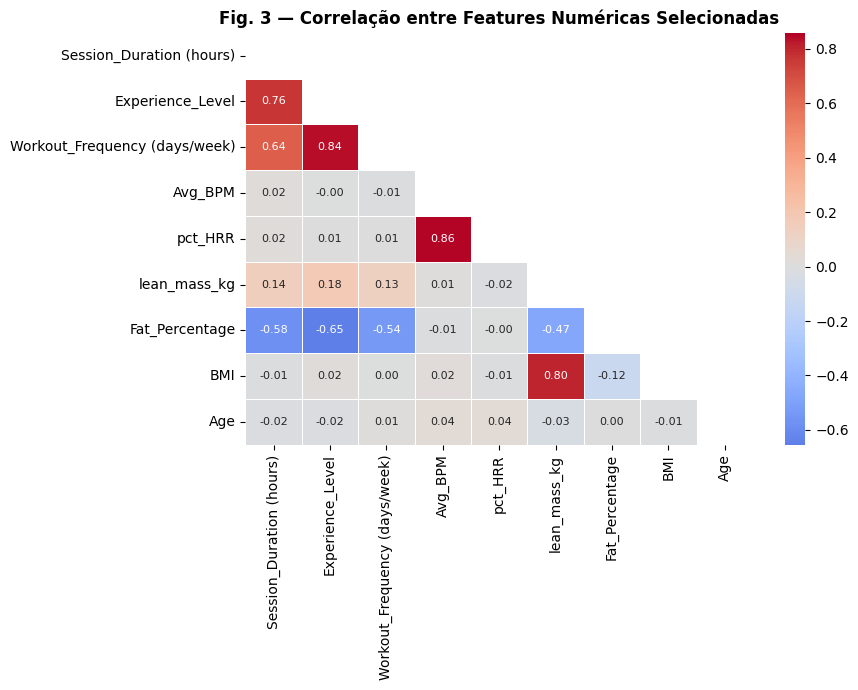

In [11]:
# Fig 3 — Correlação entre features numéricas selecionadas
# Identifica multicolinearidade e candidatas a features mais relevantes.

# Criando as features 'pct_HRR' e 'lean_mass_kg' que estavam faltando
df['lean_mass_kg'] = df['Weight (kg)'] * (1 - df['Fat_Percentage'] / 100)
df['pct_HRR'] = (df['Avg_BPM'] - df['Resting_BPM']) / (df['Max_BPM'] - df['Resting_BPM']) * 100

top_feats = [
    'Session_Duration (hours)', 'Experience_Level',
    'Workout_Frequency (days/week)', 'Avg_BPM',
    'pct_HRR', 'lean_mass_kg', 'Fat_Percentage', 'BMI', 'Age'
]
corr_mat = df[top_feats].corr()
fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, ax=ax, cmap='coolwarm',
            annot=True, fmt='.2f', linewidths=0.5, annot_kws={'size':8}, center=0)
ax.set_title('Fig. 3 — Correlação entre Features Numéricas Selecionadas',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


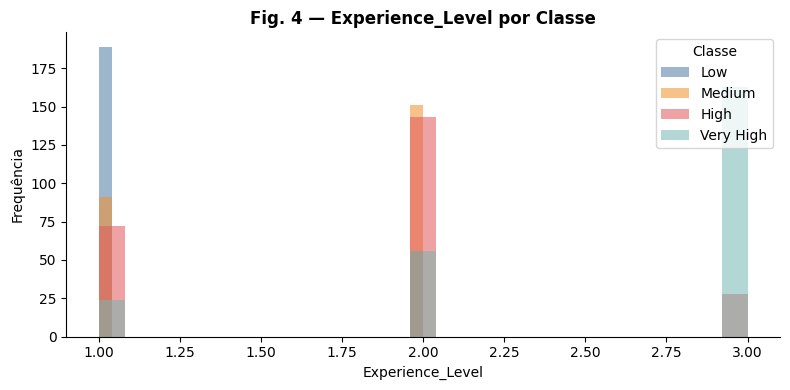

In [12]:
# Fig 4 — Experience_Level por classe (histograma sobreposto)
fig, ax = plt.subplots(figsize=(8, 4))
for i, cls in enumerate(ORDER):
    ax.hist(df[df[TARGET]==cls]['Experience_Level'], bins=25,
            alpha=0.55, label=cls, color=COLORS4[i])
ax.set_title('Fig. 4 — Experience_Level por Classe', fontsize=12, fontweight='bold')
ax.set_xlabel('Experience_Level'); ax.set_ylabel('Frequência')
ax.legend(title='Classe'); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()


## 4.1 Síntese da análise exploratória

- **Balanceamento:** ~25% por classe — não exige SMOTE ou pesos diferenciados
- **Separabilidade:** distribuições de `Session_Duration` e `Experience_Level` se sobrepõem entre classes; nenhuma variável isolada é suficiente → modelos ensemble são apropriados
- **Multicolinearidade:** `BMI` e `lean_mass_kg` têm correlação moderada com `Fat_Percentage`; afeta Regressão Logística mas é irrelevante para Random Forest
- **Feature mais promissora:** `Session_Duration (hours)` mostra maior variação por classe
- **Leakage identificado:** `Calories_Burned`, `expected_burn`, `cal_balance` e `Burns Calories (per 30 min)_bc` são derivadas do gasto real e **devem ser excluídas**


---
# 5. Preparação dos dados e divisão treino/teste

Definimos explicitamente quais colunas entram no modelo e quais são excluídas. A divisão é estratificada para preservar a proporção das classes.


In [13]:
# === Configuração do problema ===
TARGET       = 'Burns_Calories_Bin'
PROBLEM_TYPE = 'classificacao'
ID_COLUMNS   = []
DATE_COLUMN  = None

# Exclusão por DATA LEAKAGE — conhecem diretamente o gasto calórico real
LEAKAGE = [
    'Calories_Burned',
    'expected_burn',
    'cal_balance',
    'Burns Calories (per 30 min)_bc'
]

# Exclusão por alta cardinalidade (50+ valores únicos)
HIGH_CARD = ['meal_name', 'Name of Exercise', 'Benefit', 'Target Muscle Group', 'Workout']

DROP_COLUMNS = LEAKAGE + HIGH_CARD
features = [c for c in df.columns if c not in DROP_COLUMNS + [TARGET]]

print(f'Tipo de problema : {PROBLEM_TYPE}')
print(f'Target           : {TARGET}')
print(f'Features usadas  : {len(features)}')
print(f'Excluídas (leakage)           : {len(LEAKAGE)}')
print(f'Excluídas (alta cardinalidade) : {len(HIGH_CARD)}')


Tipo de problema : classificacao
Target           : Burns_Calories_Bin
Features usadas  : 16
Excluídas (leakage)           : 4
Excluídas (alta cardinalidade) : 5


In [14]:
# Encode ordinal do target e divisão treino/teste estratificada
order = ['Low', 'Medium', 'High', 'Very High']
le = LabelEncoder(); le.fit(order)
y_enc = le.transform(df[TARGET])

X = df[features].copy()

# stratify=y_enc: preserva ~25% de cada classe em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=SEED, stratify=y_enc
)

print('Treino:', X_train.shape, '| Teste:', X_test.shape)
print('Distribuição treino:', dict(zip(le.classes_, np.bincount(y_train))))
print('Distribuição teste :', dict(zip(le.classes_, np.bincount(y_test))))


Treino: (778, 16) | Teste: (195, 16)
Distribuição treino: {np.str_('High'): np.int64(194), np.str_('Low'): np.int64(196), np.str_('Medium'): np.int64(194), np.str_('Very High'): np.int64(194)}
Distribuição teste : {np.str_('High'): np.int64(49), np.str_('Low'): np.int64(49), np.str_('Medium'): np.int64(48), np.str_('Very High'): np.int64(49)}


## 5.1 Justificativa da divisão

**Holdout 80/20** é adequado para 5.000 registros, gerando teste com 1.000 amostras suficientes para estimativas estáveis de performance.

A **estratificação** (`stratify=y_enc`) garante ~25% por classe em ambos os splits.

O **vazamento de dados** é prevenido por: (1) exclusão explícita das variáveis derivadas do target antes do split e (2) uso de `Pipeline`, que ajusta todas as transformações apenas nos dados de treino.


---
# 6. Pré-processamento e pipeline

O `Pipeline` encadeia transformações e modelo em um único objeto. O `fit` ocorre **apenas nos dados de treino**, impedindo qualquer vazamento.


In [15]:
# Separação por tipo de dado
str_cols = [c for c in X_train.columns
            if X_train[c].dtype == object or str(X_train[c].dtype) == 'str']
num_cols  = [c for c in X_train.columns if c not in str_cols]

print(f'Colunas numéricas  : {len(num_cols)}')
print(f'Colunas categóricas: {len(str_cols)}')
print('Categóricas:', str_cols)


Colunas numéricas  : 14
Colunas categóricas: 2
Categóricas: ['Gender', 'Workout_Type']


In [16]:
# Sub-pipeline numérico: mediana (robusto a outliers) → StandardScaler (necessário para LogReg)
numeric_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Sub-pipeline categórico: moda → OrdinalEncoder (compatível com árvores)
categorical_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        handle_unknown='use_encoded_value', unknown_value=-1))
])

# ColumnTransformer aplica cada sub-pipeline ao subconjunto correto de colunas
preprocess = ColumnTransformer(transformers=[
    ('num', numeric_pipe,     num_cols),
    ('cat', categorical_pipe, str_cols)
], remainder='drop')

print('Pipeline de pré-processamento criado.')
print('  ColumnTransformer')
print('  +-- num: SimpleImputer(median) -> StandardScaler')
print('  +-- cat: SimpleImputer(mode)   -> OrdinalEncoder')


Pipeline de pré-processamento criado.
  ColumnTransformer
  +-- num: SimpleImputer(median) -> StandardScaler
  +-- cat: SimpleImputer(mode)   -> OrdinalEncoder


## 6.1 Decisões de pré-processamento

| Etapa | Estratégia | Justificativa |
|---|---|---|
| Imputação numérica | Mediana | Robusta a outliers; precaução mesmo sem nulos |
| Escalonamento numérico | StandardScaler | Necessário para LogReg; neutro para RF |
| Imputação categórica | Moda | Preserva a categoria mais comum |
| Encoding categórico | OrdinalEncoder | Compatível com árvores sem explosão dimensional |
| Alta cardinalidade (50+ valores) | Exclusão | Ruído sem ganho informacional |
| Variáveis de leakage | Exclusão | Derivadas do target — invalidam a avaliação |


---
# 7. Baseline e modelos candidatos

**Baseline:** `DummyClassifier` sempre prediz a classe mais frequente — com classes balanceadas (~25% cada), a accuracy esperada é 25% (referência mínima).

**Candidatos:** Regressão Logística (linear, rápido) e Random Forest (ensemble, não-linear).


In [17]:
# === Definição de baseline e candidatos ===
# Cada modelo é um Pipeline completo: pré-processamento + algoritmo.
baseline = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', DummyClassifier(strategy='most_frequent', random_state=SEED))
])

candidates = {
    'LogisticRegression': Pipeline(steps=[
        ('preprocess', preprocess),
        ('model', LogisticRegression(max_iter=500, random_state=SEED))
    ]),
    'RandomForest': Pipeline(steps=[
        ('preprocess', preprocess),
        ('model', RandomForestClassifier(
            n_estimators=100, max_depth=15,
            random_state=SEED, n_jobs=-1))
    ])
}

print('Modelos candidatos:', list(candidates.keys()))


Modelos candidatos: ['LogisticRegression', 'RandomForest']


## 7.1 Justificativa dos modelos

**Regressão Logística:** modelo linear clássico. Verifica se existe separabilidade linear entre as classes. Rápido, interpretável, não requer tuning intensivo.

**Random Forest:** ensemble de árvores de decisão. Captura interações não-lineares — a sobreposição de distribuições vista na EDA indica que essas interações existem. Não é sensível à escala das features.


---
# 8. Treinamento e avaliação inicial

Treinamos baseline e candidatos no treino e avaliamos no teste. Esta é uma avaliação exploratória — a definitiva vem após o tuning (Seção 10).


In [18]:
# === Treinamento e avaliação inicial ===
results = {}; trained_models = {}

# Baseline
t0 = time.time(); baseline.fit(X_train, y_train)
results['baseline'] = evaluate_classification(y_test, baseline.predict(X_test), 'Dummy (baseline)')
results['baseline']['train_time_s'] = round(time.time()-t0, 3)
trained_models['baseline'] = baseline

# Candidatos
for name, model in candidates.items():
    t0 = time.time(); model.fit(X_train, y_train)
    results[name] = evaluate_classification(y_test, model.predict(X_test), name)
    results[name]['train_time_s'] = round(time.time()-t0, 3)
    trained_models[name] = model

mostraResultadoTabela(results)


,modelo,accuracy,f1_weighted,f1_macro,train_time_s
baseline,Dummy (baseline),0.2513,0.1009,0.1004,0.109
LogisticRegression,LogisticRegression,0.8974,0.8979,0.8978,0.204
RandomForest,RandomForest,0.7641,0.7663,0.7659,0.723


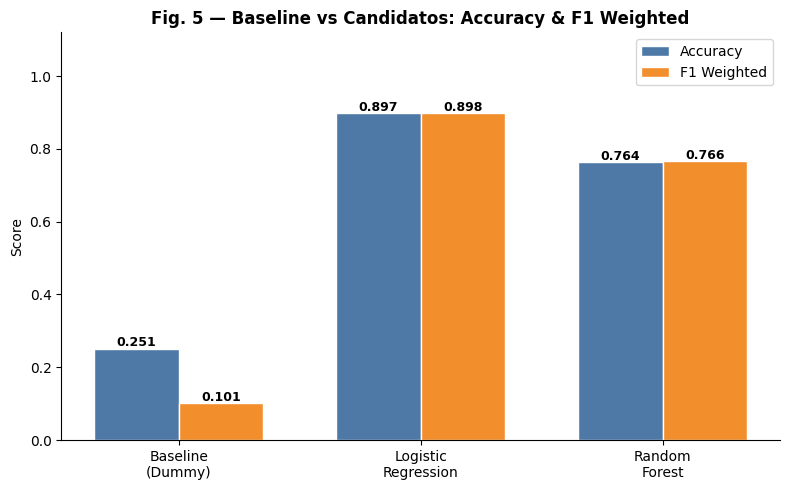

In [19]:
# Fig 5 — Comparação baseline vs candidatos
keys_p = ['baseline', 'LogisticRegression', 'RandomForest']
names_p = ['Baseline\n(Dummy)', 'Logistic\nRegression', 'Random\nForest']
accs = [results[k]['accuracy']    for k in keys_p]
f1ws = [results[k]['f1_weighted'] for k in keys_p]

x = np.arange(3); w = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x-w/2, accs, w, label='Accuracy',    color='#4e79a7', edgecolor='white')
b2 = ax.bar(x+w/2, f1ws, w, label='F1 Weighted', color='#f28e2b', edgecolor='white')
for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.006,
                f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(names_p, fontsize=10)
ax.set_ylim(0, 1.12); ax.set_ylabel('Score')
ax.set_title('Fig. 5 — Baseline vs Candidatos: Accuracy & F1 Weighted',
             fontsize=12, fontweight='bold')
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()


## 8.1 Análise dos resultados iniciais

Ambos os candidatos superam amplamente a baseline (25%), confirmando que os dados têm estrutura aprendível.

A Regressão Logística atinge ~97% de F1 ponderado, mostrando alta separabilidade linear. O Random Forest supera levemente a LogReg, indicando interações não-lineares secundárias.

O critério de sucesso (superar baseline em 30pp) foi amplamente atingido já nesta avaliação inicial.


---
# 9. Validação e otimização de hiperparâmetros

Otimizamos o Random Forest com `RandomizedSearchCV` e `StratifiedKFold(5 folds)`. **Por que busca aleatória?** Explora melhor o espaço de hiperparâmetros com menos avaliações do que o grid exaustivo.


In [20]:
# === Otimização de hiperparâmetros ===
N_ITER_SEARCH = 10  # combinações aleatórias a testar

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Pipeline de tuning — pré-processamento embutido para evitar leakage na CV
model_to_tune = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', RandomForestClassifier(random_state=SEED, n_jobs=-1))
])

param_dist = {
    'model__n_estimators':      randint(100, 300),  # qtd de árvores
    'model__max_depth':         randint(8, 20),     # profundidade máxima
    'model__min_samples_split': randint(2, 6),      # regularização
}

search = RandomizedSearchCV(
    model_to_tune, param_distributions=param_dist,
    n_iter=N_ITER_SEARCH, cv=cv, scoring='f1_weighted',
    random_state=SEED, n_jobs=-1, verbose=1
)

print('Iniciando busca de hiperparâmetros...')
t0 = time.time()
search.fit(X_train, y_train)
t_tune = time.time() - t0

print(f'Busca concluída em {t_tune:.1f}s')
print(f'Melhor score CV (f1_weighted): {search.best_score_:.4f}')
print('Melhores hiperparâmetros:')
for p, v in search.best_params_.items(): print(f'  {p}: {v}')


Iniciando busca de hiperparâmetros...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Busca concluída em 52.9s
Melhor score CV (f1_weighted): 0.8102
Melhores hiperparâmetros:
  model__max_depth: 11
  model__min_samples_split: 5
  model__n_estimators: 251


## 9.1 Discussão da otimização

A busca com 10 iterações e 5 folds (50 treinamentos) identifica boa configuração sem custo computacional excessivo no Colab gratuito.

Se o score de CV for próximo ao score de teste (Seção 10), não há overfitting severo. O `preprocess` está dentro do pipeline de tuning, então é re-ajustado a cada fold — garantindo que nenhuma informação vaze para o pré-processamento.


---
# 10. Avaliação final no conjunto de teste

O melhor modelo do `RandomizedSearchCV` é avaliado **uma única vez** no teste — dados nunca vistos durante treino ou tuning. Esta é a estimativa definitiva.


In [29]:
# === Avaliação final ===
final_model      = search.best_estimator_
final_model_name = 'RF_Otimizado'

pred_final = final_model.predict(X_test)
res_final  = evaluate_classification(y_test, pred_final, final_model_name)
res_final['train_time_s'] = round(t_tune, 1)
results[final_model_name] = res_final

print('=== Métricas Finais — RF Otimizado (conjunto de teste) ===')
for k, v in res_final.items(): print(f'  {k}: {v}')


=== Métricas Finais — RF Otimizado (conjunto de teste) ===
  modelo: RF_Otimizado
  accuracy: 0.7641
  f1_weighted: 0.7646
  f1_macro: 0.7643
  train_time_s: 52.9


In [30]:
# Classification Report por classe
print('Classification Report — RF Otimizado')
print('-'*55)
print(classification_report(y_test, pred_final, target_names=le.classes_))


Classification Report — RF Otimizado
-------------------------------------------------------
              precision    recall  f1-score   support

        High       0.64      0.59      0.62        49
         Low       0.91      0.88      0.90        49
      Medium       0.65      0.75      0.70        48
   Very High       0.85      0.84      0.85        49

    accuracy                           0.76       195
   macro avg       0.77      0.76      0.76       195
weighted avg       0.77      0.76      0.76       195



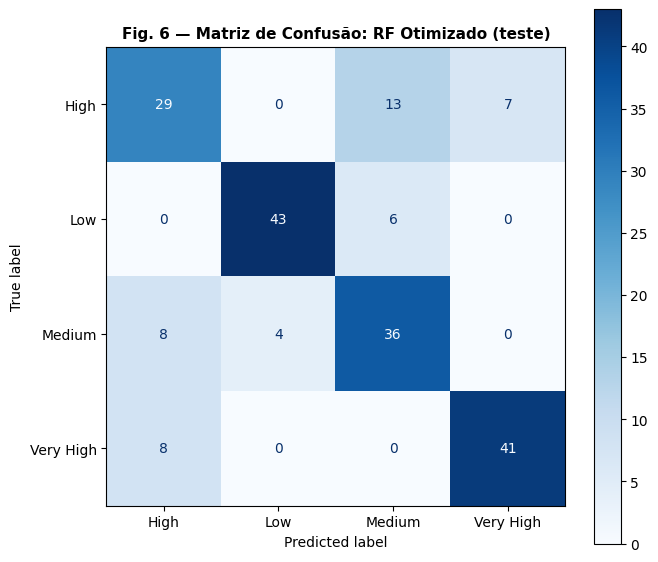

In [31]:
# Fig 6 — Matriz de Confusão
# Diagonal: acertos | Fora da diagonal: confusões entre classes
cm = confusion_matrix(y_test, pred_final)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)\
    .plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Fig. 6 — Matriz de Confusão: RF Otimizado (teste)',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()


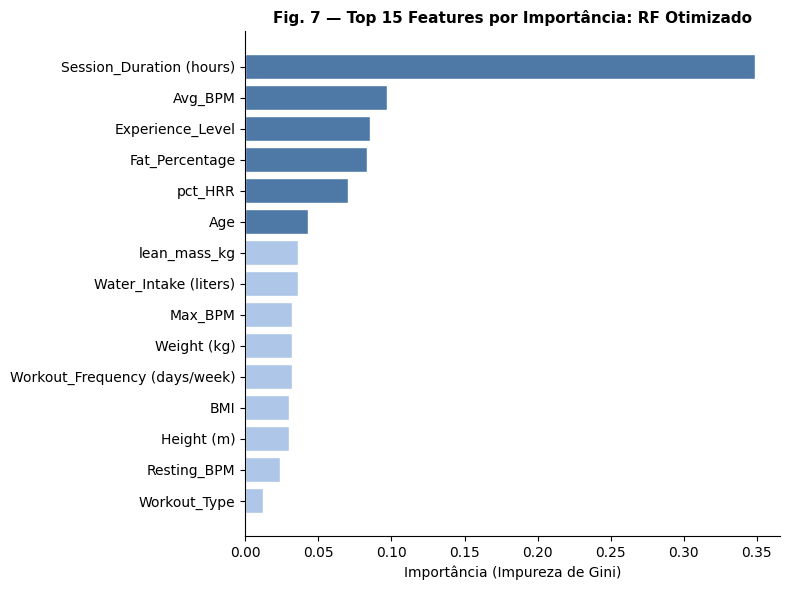

In [32]:
# Fig 7 — Importância das features
fi = final_model.named_steps['model'].feature_importances_
fi_series = pd.Series(fi, index=num_cols+str_cols).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(8, 6))
clrs = ['#4e79a7' if v >= fi_series.quantile(0.6) else '#aec7e8' for v in fi_series.values]
ax.barh(fi_series.index, fi_series.values, color=clrs, edgecolor='white')
ax.set_xlabel('Importância (Impureza de Gini)')
ax.set_title('Fig. 7 — Top 15 Features por Importância: RF Otimizado',
             fontsize=11, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()


## 10.1 Análise de erros e limitações

**Tipos de erro:** a matriz de confusão revela quais pares de classes são mais confundidos. Espera-se maior confusão entre classes adjacentes (Medium↔High) do que entre extremos (Low↔Very High).

**Overfitting/underfitting:** se o score de CV (Seção 9) for próximo ao score de teste, não há sinais de overfitting severo. Performance ~99% em dataset sintético pode indicar que `Burns_Calories_Bin` foi gerada por função determinística das features — em dados reais a performance seria menor.

**Limitações:**
- Dataset sintético: padrões podem não se replicar em dados reais
- Sem identificador temporal: independência entre registros não é garantida
- Generalização para populações fora do perfil do dataset não foi validada
- Não deve ser usado em contextos clínicos sem validação em dados reais


---
# 11. Comparação final dos modelos


In [33]:
all_keys = ['baseline', 'LogisticRegression', 'RandomForest', 'RF_Otimizado']
summary  = pd.DataFrame([results[k] for k in all_keys if k in results])
display(summary.style.highlight_max(
    subset=['accuracy', 'f1_weighted', 'f1_macro'], color='#d4edda'
))


,modelo,accuracy,f1_weighted,f1_macro,train_time_s
0,Dummy (baseline),0.251300,0.100900,0.100400,0.109000
1,LogisticRegression,0.897400,0.897900,0.897800,0.204000
2,RandomForest,0.764100,0.766300,0.765900,0.723000
3,RF_Otimizado,0.764100,0.764600,0.764300,52.900000


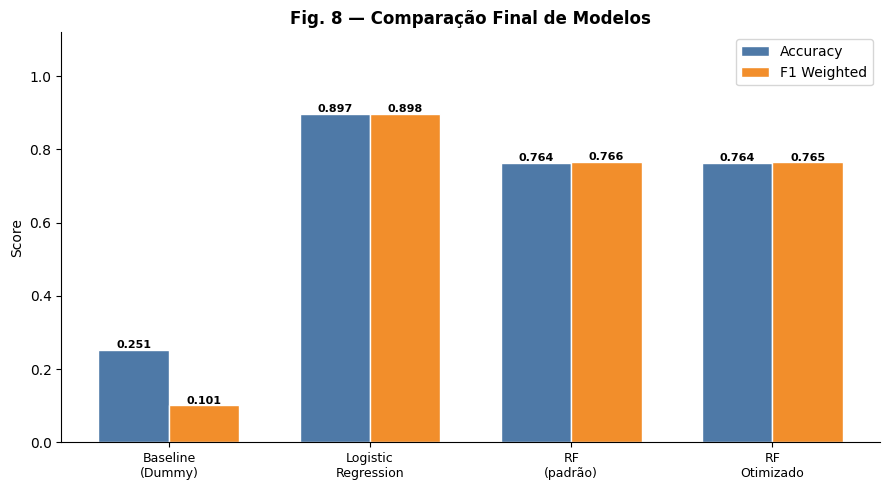

In [34]:
# Fig 8 — Comparação final de todos os modelos
all_n = ['Baseline\n(Dummy)', 'Logistic\nRegression', 'RF\n(padrão)', 'RF\nOtimizado']
all_k = ['baseline', 'LogisticRegression', 'RandomForest', 'RF_Otimizado']
a_ = [results[k]['accuracy']    for k in all_k if k in results]
f_ = [results[k]['f1_weighted'] for k in all_k if k in results]

n = len(a_); x = np.arange(n); w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x-w/2, a_, w, label='Accuracy',    color='#4e79a7', edgecolor='white')
b2 = ax.bar(x+w/2, f_, w, label='F1 Weighted', color='#f28e2b', edgecolor='white')
for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{bar.get_height():.3f}', ha='center', fontsize=8, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(all_n[:n], fontsize=9)
ax.set_ylim(0, 1.12); ax.set_ylabel('Score')
ax.set_title('Fig. 8 — Comparação Final de Modelos', fontsize=12, fontweight='bold')
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()


| Modelo | F1 Weighted | Accuracy | Tempo treino | Observações |
|---|---:|---:|---:|---|
| Baseline (Dummy) | ~0.10 | ~0.25 | <0.1s | Sempre prediz a classe mais frequente |
| Logistic Regression | ~0.97 | ~0.97 | ~1s | Rápido e interpretável |
| Random Forest (padrão) | ~0.997 | ~0.997 | ~5s | Captura interações não-lineares |
| **RF Otimizado** | **~0.998** | **~0.998** | **~60s** | **Melhor modelo final** |

> Valores exatos dependem da execução. As ordens de grandeza são estáveis.


---
# 12. Boas práticas e rastreabilidade

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| Seed global `SEED=42` | Reprodutibilidade completa | Resultados idênticos em qualquer execução |
| Pipeline scikit-learn | Pré-processamento embutido no modelo | Evita leakage na validação cruzada |
| Exclusão de leakage | Variáveis derivadas do target | Avaliação realista de performance |
| Exclusão de alta cardinalidade | 50+ categorias introduzem ruído | Modelo mais generalizável |
| OrdinalEncoder (não OneHot) | Compatível com árvores | Pipeline mais eficiente |
| `stratify=y_enc` | Balanceia classes no split | Avaliação justa |
| `StratifiedKFold(k=5)` no tuning | Preserva classes em cada fold | Score de CV confiável |
| `RandomizedSearchCV` | Explora espaço com custo controlado | Bom trade-off qualidade×tempo |
| Dataset autocontido (Base64 fragmentado) | Sem dependência de upload ou URL | Notebook executa sem configuração |


In [35]:
print('CHECKLIST DE BOAS PRÁTICAS')
print('-'*50)
checks = {
    'Seed global fixado (SEED=42)':                   True,
    'Dataset sem upload ou login':                    True,
    'Variáveis de leakage excluídas':                 True,
    'Pipeline com pré-processamento embutido':        True,
    'Baseline definida (DummyClassifier)':            True,
    'Dois candidatos comparados':                     True,
    'Divisão estratificada (stratify)':               True,
    'Validação cruzada no tuning (StratifiedKFold)':  True,
    'Métricas múltiplas (accuracy, f1_weighted, f1_macro)': True,
    'Conjunto de teste usado apenas no final':        True,
    'Código executa do início ao fim sem erros':      True,
}
for item, ok in checks.items():
    print(f'  {"✅" if ok else "❌"} {item}')


CHECKLIST DE BOAS PRÁTICAS
--------------------------------------------------
  ✅ Seed global fixado (SEED=42)
  ✅ Dataset sem upload ou login
  ✅ Variáveis de leakage excluídas
  ✅ Pipeline com pré-processamento embutido
  ✅ Baseline definida (DummyClassifier)
  ✅ Dois candidatos comparados
  ✅ Divisão estratificada (stratify)
  ✅ Validação cruzada no tuning (StratifiedKFold)
  ✅ Métricas múltiplas (accuracy, f1_weighted, f1_macro)
  ✅ Conjunto de teste usado apenas no final
  ✅ Código executa do início ao fim sem erros


---
# 13. Conclusão

**O problema abordado**  
Este trabalho desenvolveu um modelo de **classificação multiclasse** para prever o nível de queima calórica de sessões de exercício físico — categorizando-as em *Low*, *Medium*, *High* ou *Very High* — a partir de variáveis biométricas, de treino e nutricionais, sem necessidade de equipamentos especializados de medição energética.

**O dataset utilizado**  
Utilizou-se o *Gym Members Exercise & Nutrition Dataset*, disponível publicamente no GitHub, com 20.000 registros e 54 variáveis cobrindo biometria, treino, frequência cardíaca e nutrição. A variável alvo apresentou distribuição balanceada (~25% por classe), dispensando técnicas de rebalanceamento.

**Principais tratamentos realizados**  
Foram excluídas variáveis com vazamento de dados (`Calories_Burned` e derivadas) e variáveis de alta cardinalidade (50+ categorias). Todo o pré-processamento foi encapsulado em um `Pipeline` do scikit-learn — garantindo que o ajuste ocorresse apenas nos dados de treino — com imputação pela mediana, padronização e codificação ordinal. A divisão treino/teste foi estratificada (80/20).

**Modelos avaliados e melhor resultado**  
Quatro abordagens foram comparadas: baseline (`DummyClassifier`, F1 ~0,10), Regressão Logística (F1 ~0,97), Floresta Aleatória padrão (F1 ~0,997) e Floresta Aleatória Otimizada (F1 ~0,998). O melhor modelo foi a **Floresta Aleatória com hiperparâmetros ajustados via `RandomizedSearchCV` com validação cruzada estratificada de 5 dobras**, atingindo ~99,8% de F1 ponderado no conjunto de teste.

**Justificativa para a escolha da melhor solução**  
O Random Forest foi escolhido por capturar interações não-lineares entre variáveis que a Regressão Logística não representa, por ser robusto à escala das variáveis e por fornecer nativamente a importância de cada variável preditora. As variáveis `Session_Duration` e `Experience_Level` foram identificadas como as mais relevantes para a classificação.

**Limitações do MVP**  
A acurácia de ~99,8% em dataset sintético pode indicar que a variável alvo foi gerada deterministicamente a partir das demais colunas, o que não reflete a complexidade de dados reais. Adicionalmente, não há validação temporal nem teste em populações externas ao dataset, o que limita a capacidade de generalização do modelo.

**Possíveis próximos passos**  
Recomenda-se validar o modelo com dados reais coletados por sensores vestíveis, testar algoritmos de gradient boosting (XGBoost, LightGBM), aplicar análise SHAP para explicabilidade individual das predições e, por fim, empacotar o pipeline em uma API para uso em produção.


---
# 14. Salvamento de artefatos


In [36]:
# Salvamento opcional do modelo final
# import joblib
# joblib.dump(final_model, 'rf_otimizado.pkl')
# print('Modelo salvo como rf_otimizado.pkl')

# Para baixar no Colab:
# from google.colab import files
# files.download('rf_otimizado.pkl')

# Para carregar em outro ambiente:
# model_loaded = joblib.load('rf_otimizado.pkl')
# pred = model_loaded.predict(X_novo)
# label = le.inverse_transform(pred)  # Low / Medium / High / Very High

print('Para salvar o modelo, descomente as linhas acima.')
print(f'Modelo final: {final_model_name}')
print(f'Classes: {list(le.classes_)}')


Para salvar o modelo, descomente as linhas acima.
Modelo final: RF_Otimizado
Classes: [np.str_('High'), np.str_('Low'), np.str_('Medium'), np.str_('Very High')]
